In [ ]:
import pandas as pd # to work with data in tables
import numpy as np # for math operations
import matplotlib.pyplot as plt # for making graphs
import seaborn as sns # for nicer graphs
sns.set()

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


In [ ]:
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')


In [ ]:
df['mpg'].mean()

np.float64(23.514572864321607)

In [ ]:
df['mpg'].median()

np.float64(23.0)

In [ ]:
df['mpg'].mode()

0    13.0
Name: mpg, dtype: float64

In [ ]:
df['mpg'].std()

np.float64(7.815984312565782)

In [ ]:
df['mpg'].var()

np.float64(61.089610774274405)

In [ ]:
q3 = df['mpg'].quantile(0.75)
q1 = df['mpg'].quantile(0.25)
iqr = q3 - q1
print(iqr)

11.5


In [ ]:
brand_group_freq = df['origin'].value_counts().sort_index().rename("Frequency").to_frame()
brand_group_freq

,Frequency
origin,
europe,70
japan,79
usa,249


In [ ]:
brand_group_freq = df['horsepower'].value_counts().sort_index().rename("Frequency").to_frame()
brand_group_freq

,Frequency
horsepower,
46.0,2
48.0,3
49.0,1
52.0,4
53.0,2
...,...
210.0,1
215.0,3
220.0,1


In [ ]:
age_bins = [40, 80, 100, 120, 140, 160, 180, 200, 220, 240]
age_labels = ['40', '80', '100', '120', '140', '160', '180', '200', '220+']

df['horsepower_Group'] = pd.cut(df['horsepower'], bins=age_bins, labels=age_labels, right=False)
brand_group_freq = df['horsepower_Group'].value_counts().sort_index().rename("Frequency").to_frame()
brand_group_freq

,Frequency
horsepower_Group,
40,112
80,113
100,61
120,22
140,45
160,17
180,11
200,6
220+,5


In [ ]:
df['mpg'].skew()

np.float64(0.45706634399491913)

In [ ]:
df['mpg'].kurt()

np.float64(-0.5107812652123154)

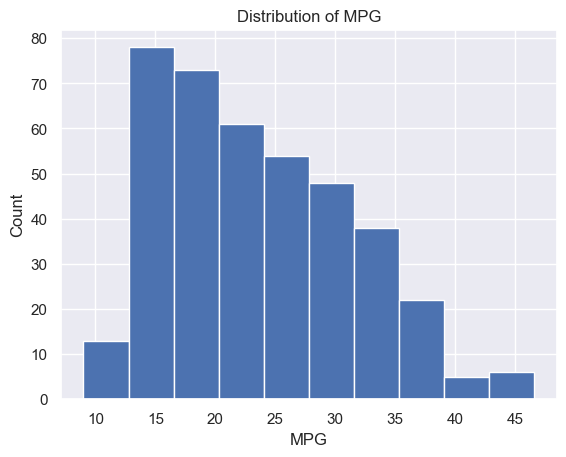

In [ ]:
df['mpg'].hist(bins=10)
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Count')
plt.show()



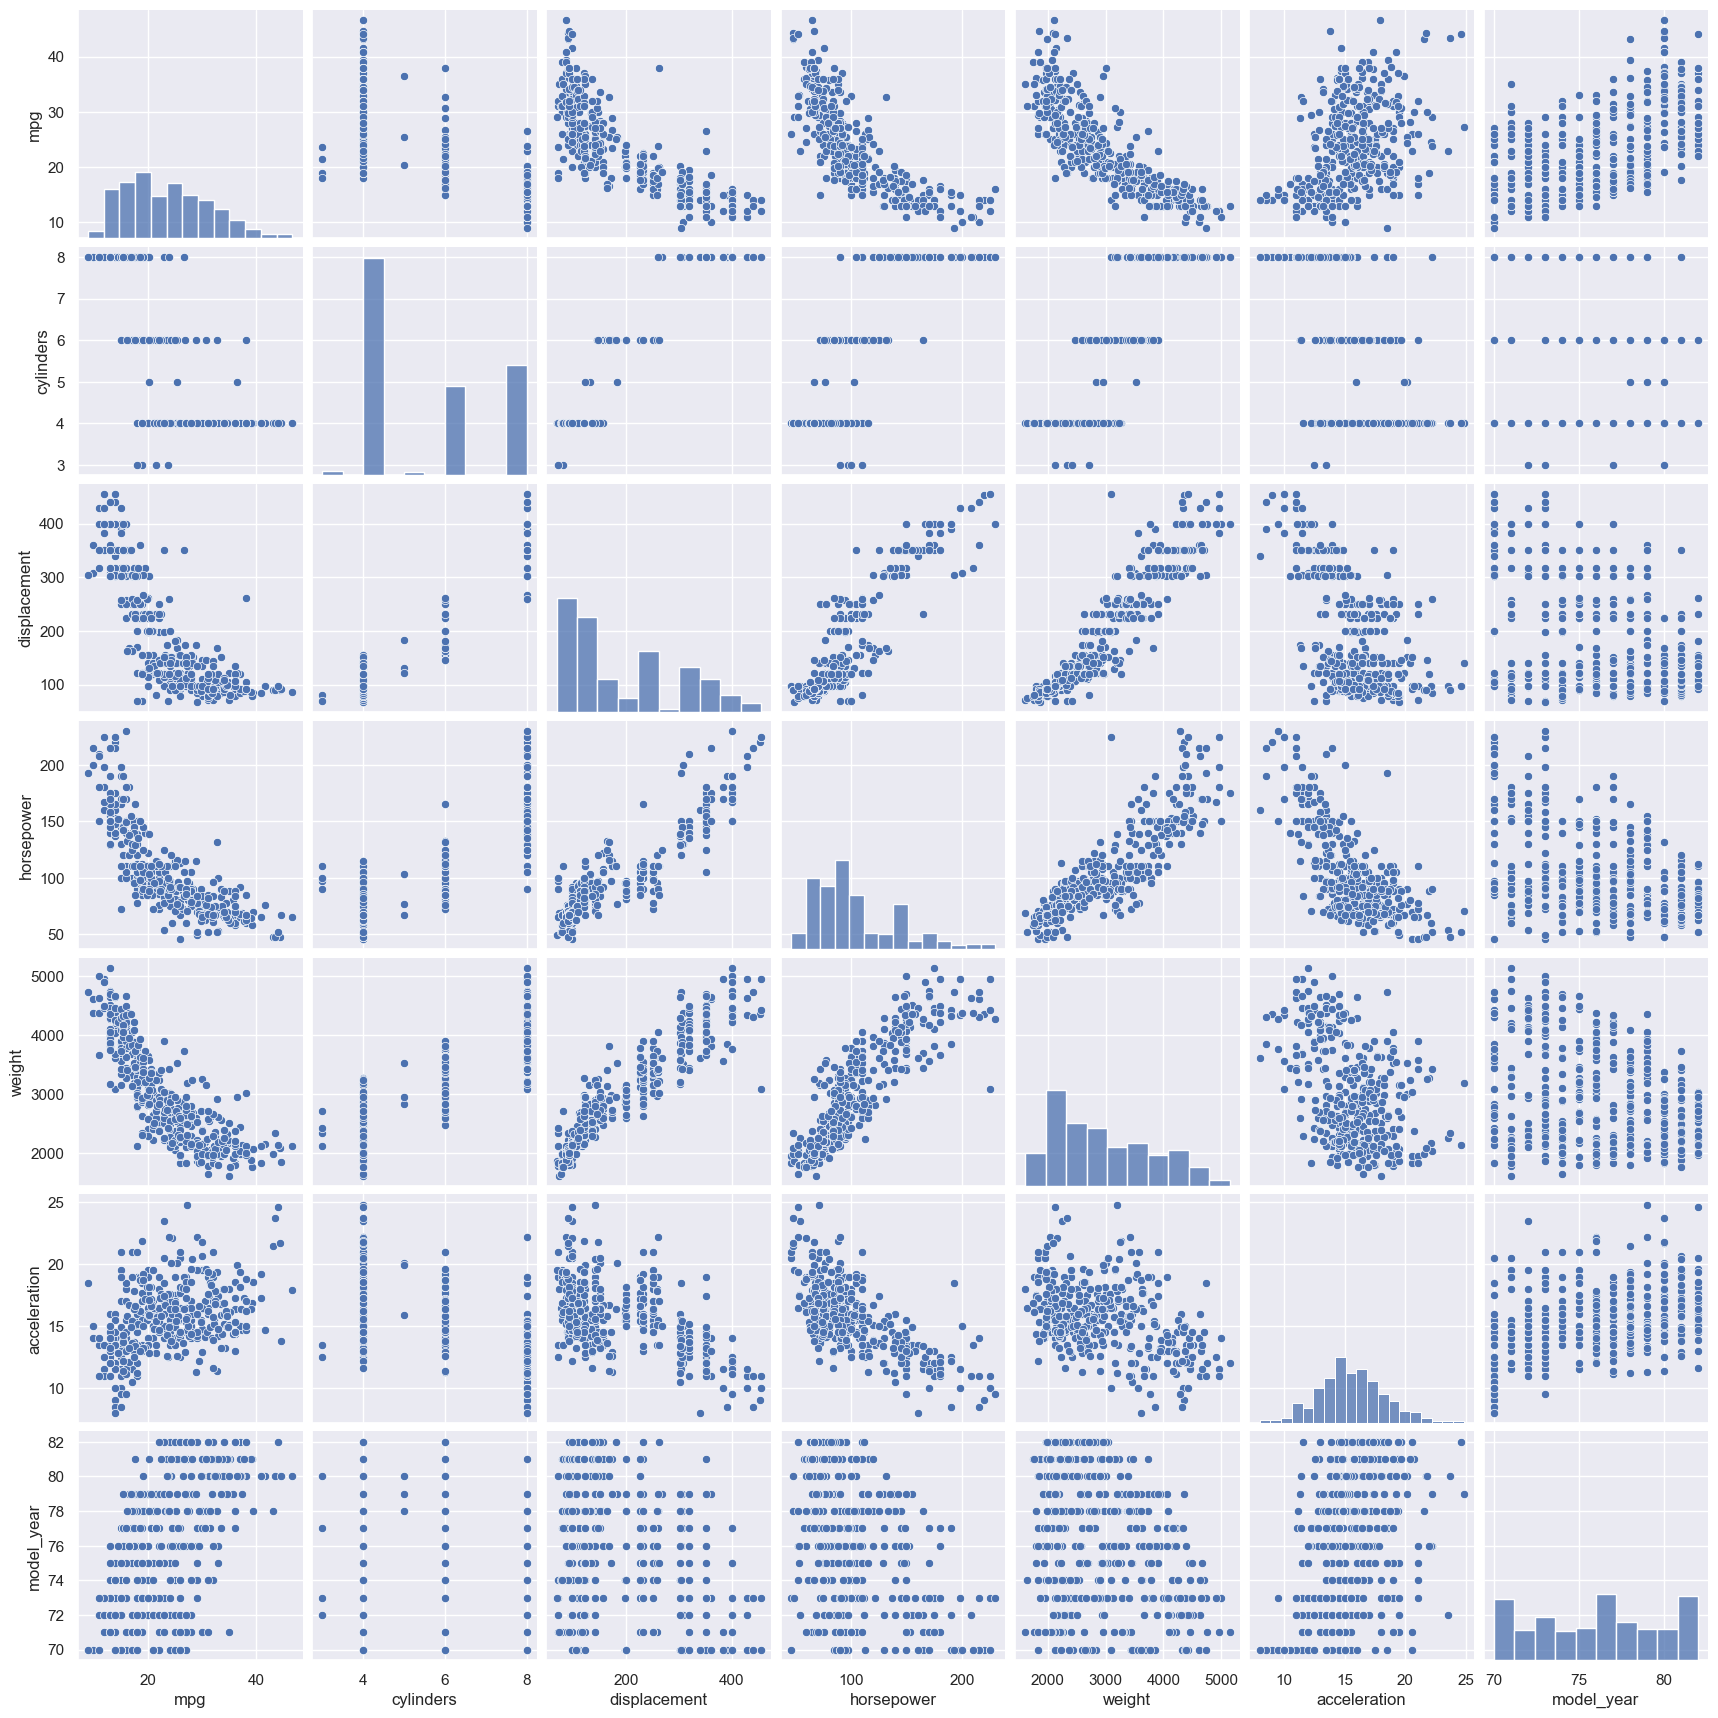

In [ ]:

sns.pairplot(df)
plt.show()

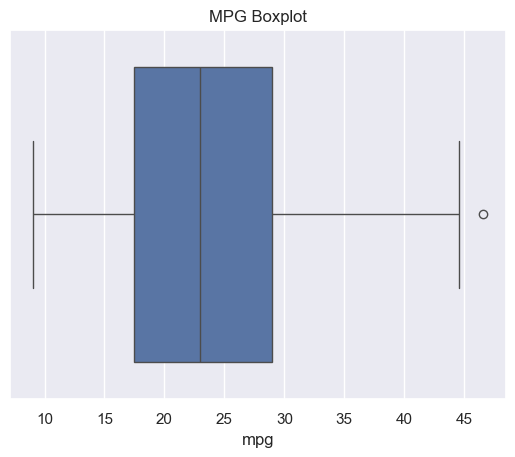

In [ ]:

sns.boxplot(x=df['mpg'])
plt.title('MPG Boxplot')
plt.show()

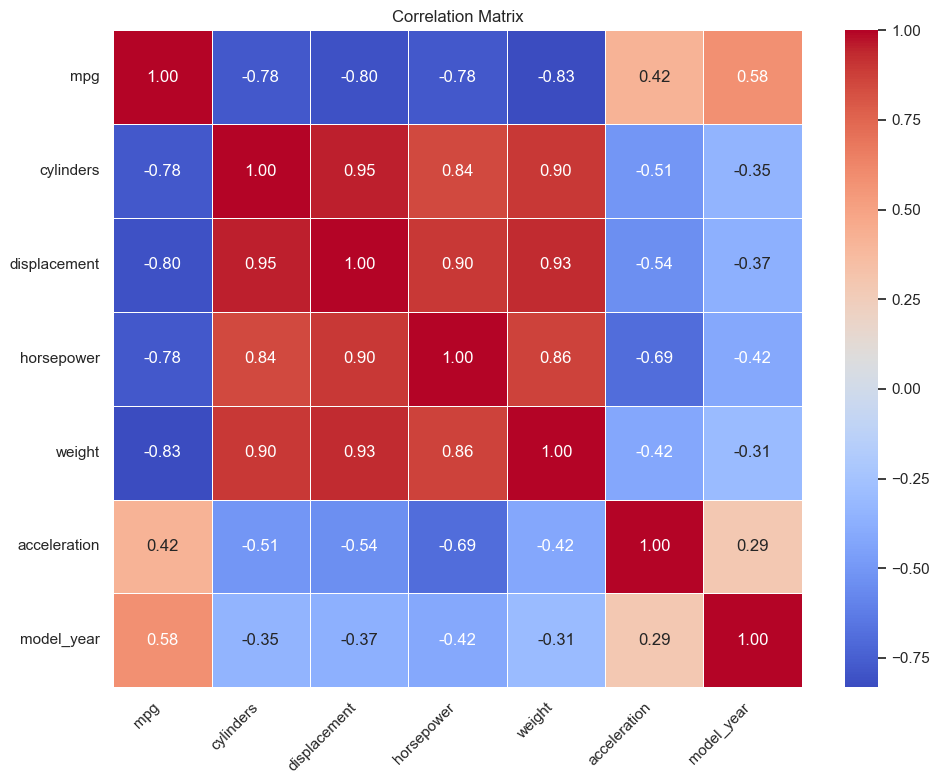

In [ ]:
numeric_data = df.select_dtypes(include='number')

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### **Fuel efficiency (mpg) drops with bigger, heavier, older cars.**

### **Newer cars tend to be more efficient and lightweight.**

### **Many engine related features are strongly interconnected: cylinders, displacement, horsepower, and weight move together.**

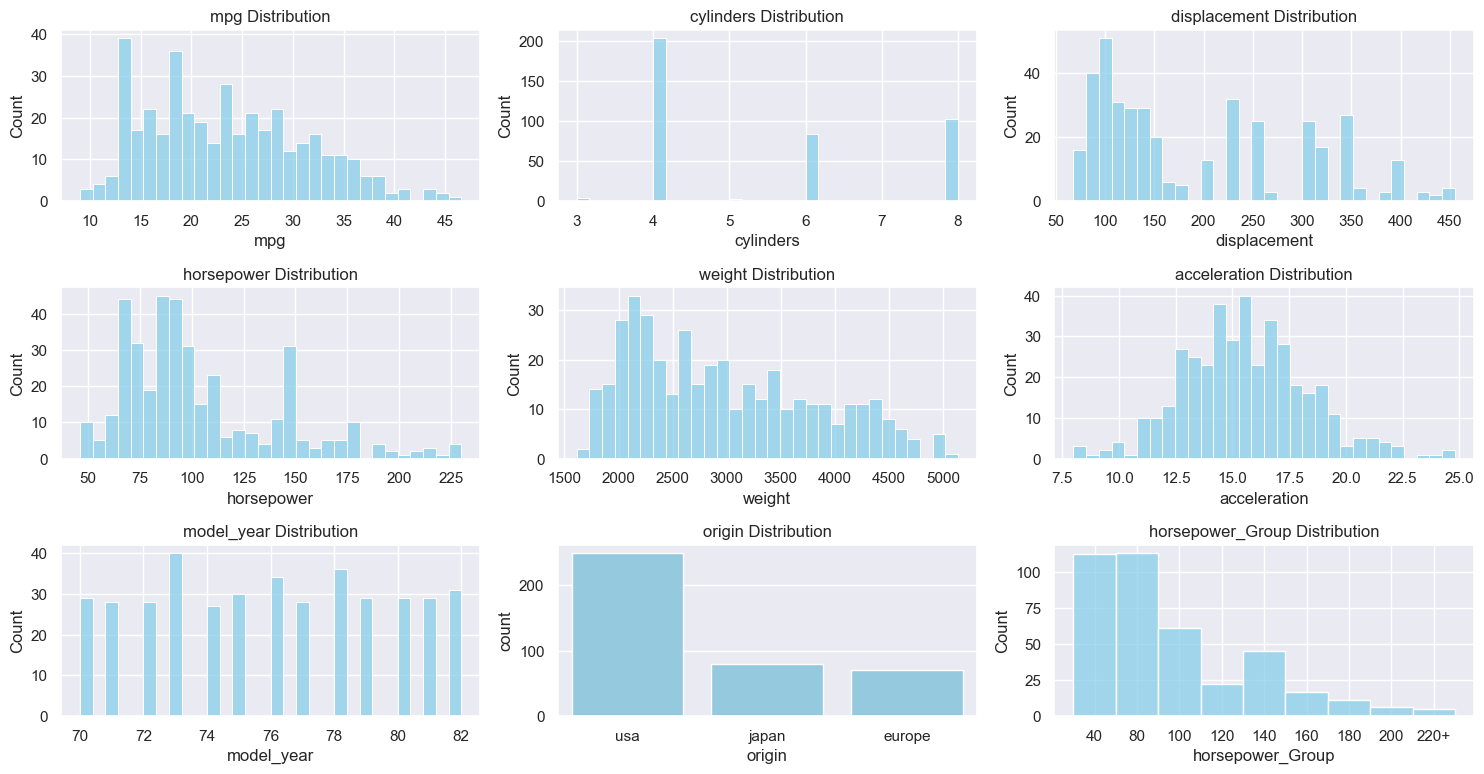

In [ ]:
features_basic = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin',  'horsepower_Group'
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_basic, 1):
    plt.subplot(4, 3, i)
    if df[feature].dtype == 'object':
        sns.countplot(data=df, x=feature, color='skyblue')
    else:
        sns.histplot(data=df, x=feature, bins=30, kde=False, color='skyblue')
    plt.title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

### **mpg Distribution**
Most cars in the dataset have mpg values between 15–30, with a peak around 20 mpg. Few cars are very fuel-efficient (over 40 mpg).

### **cylinders Distribution**
The majority of cars have 4 cylinders, followed by 8 cylinders, showing the prevalence of compact and high-performance engines.

### **displacement Distribution**
Most engines have a displacement between 100–250 cubic inches, with fewer large engines over 300+.

### **horsepower Distribution**
Horsepower is concentrated between 60–120 HP, peaking around 80–100 HP. Very powerful cars (200+ HP) are rare.

### **weight Distribution**
Most cars weigh between 2000–3500 lbs, indicating a focus on mid-sized vehicles. Very light or heavy cars are uncommon.

### **acceleration Distribution**
Most cars take about 14–17 seconds to accelerate. Very fast or very slow accelerations are rare.

### **model_year Distribution**
Most cars are from the USA, followed by Japan and Europe, showing U.S. dominance in the dataset.

### **horsepower_Group Distribution**
Most cars fall into the low to mid horsepower categories (under 100 HP). High-performance vehicles are very rare.